In [2]:
import marimo as mo
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from regex import P
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from itertools import combinations
from tqdm import tqdm
import os
import re
import yaml
from torchgeodemo import autoencoder_train_latent
import torch
#notebook to rest reconstruction error of PCA

# #load the census data
# def populate_data_table(filepath: str) -> pd.DataFrame:
#     print("Populating data table from files in", filepath)
#     data_table = None  # Initialize data_table outside the loop

#     for file in tqdm(os.listdir(filepath), desc="Processing files", unit="file"):
#         df = pd.read_csv(filepath + "/" + file, index_col="OA")
#         if data_table is None:
#             data_table = df  # Initialize data_table with the first file encountered
#         else:
#             # Merge on index
#             data_table = data_table.merge(df, left_index=True, right_index=True, how="outer")
#     return data_table

# # Load the data
# data_path = "../data/uk_census/"
# data_table = populate_data_table(data_path)

# #drop the totals (columns ending 001)
# data_table = data_table.loc[:, ~data_table.columns.str.endswith("001")]

# #save the data
# data_table.to_csv("../data/uk_census_all.csv")

# #load the data
data_table = pd.read_csv("../data/uk_census_all.csv", index_col=0)

random_seed_number = 20210321  # 2021 UK Census date used as random seed
def set_random_seeds(seed):
    # """Set random seeds for reproducibility."""
    torch.manual_seed(seed)  # Set seed for PyTorch
    # np.random.seed(seed)  # Set seed for NumPy
    # random.seed(seed)  # Set seed for Python's random module

    # # If using a GPU, set seeds for CUDA as well
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # # Ensure deterministic behavior on GPU
    # torch.backends.cudnn.deterministic = True  # Make sure CUDA uses deterministic algorithms
    # torch.backends.cudnn.benchmark = False  # Avoid using CUDA's autotuning for performance (slower, but more reproducible)

# Set the seed
set_random_seeds(seed=random_seed_number)


run_name = "60epoch_scan_extalayers"
WORKING_DIR = "../ukcensus/" + run_name
os.makedirs(WORKING_DIR, exist_ok=True)
# Output directory for generated YAMLs
OUTPUT_DIR = "../ukcensus/" + run_name + "/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)

epochs = 60

# #number of input vars
# input_dim = len(data_table.columns)
layer1_dim = 128
layer2_dim = 96
layer3_dim = 64
bottleneck_sizes = [2,4,8,16,32,64]

def plot_loss(WORKING_DIR,data_nickname,ae_nickname):
    # Load the loss data
    loss_data = pd.read_csv(WORKING_DIR + f"/logs/log_{data_nickname}_{ae_nickname}_v1/version_1/metrics.csv")[['epoch', 'train_loss_epoch', 'recon_loss_epoch']]
    #drop rows with nan
    loss_data = loss_data.dropna()
    plt.plot(loss_data["epoch"], loss_data["train_loss_epoch"], label="Training Loss")
    plt.plot(loss_data["epoch"], loss_data["recon_loss_epoch"], label="Reconstruction Loss")
    plt.show()



geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 2]}, 'max_epochs': 60, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [2, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_features=2, bias=True)
      (5): Identity()
    )
  )
  (de

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.0 K | train
2 | decoder       | MLP     | 37.2 K | train
--------------------------------------------------
74.2 K    Trainable params
0         Non-trainable params
74.2 K    Total params
0.297     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo__bottleneck_2_v1__reconstructed_outputs.csv


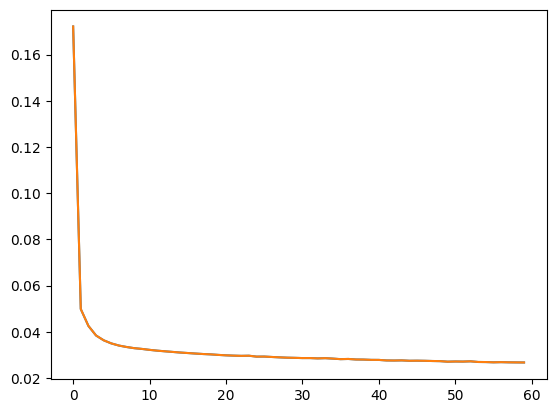


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 4]}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [4, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_features=4, bias=True)
      (5): Identity()
    )
  )
  (de

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.2 K | train
2 | decoder       | MLP     | 37.4 K | train
--------------------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo__bottleneck_4_v1__reconstructed_outputs.csv


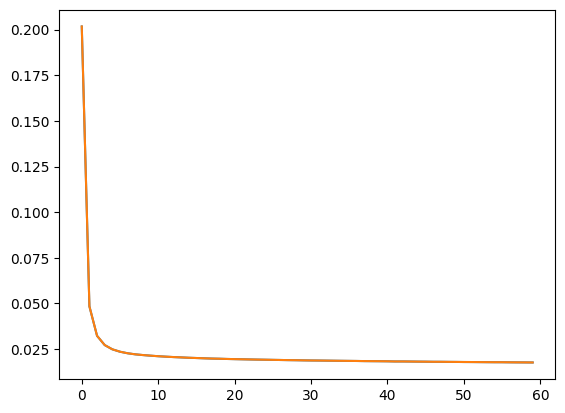


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 8]}, 'max_epochs': 60, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [8, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_features=8, bias=True)
      (5): Identity()
    )
  )
  (de

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.6 K | train
2 | decoder       | MLP     | 37.8 K | train
--------------------------------------------------
75.4 K    Trainable params
0         Non-trainable params
75.4 K    Total params
0.302     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo__bottleneck_8_v1__reconstructed_outputs.csv


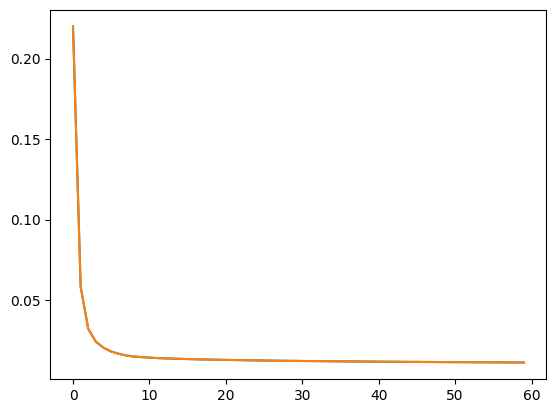


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 16]}, 'max_epochs': 60, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [16, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_features=16, bias=True)
      (5): Identity()
    )
  )


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 38.4 K | train
2 | decoder       | MLP     | 38.6 K | train
--------------------------------------------------
76.9 K    Trainable params
0         Non-trainable params
76.9 K    Total params
0.308     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo__bottleneck_16_v1__reconstructed_outputs.csv


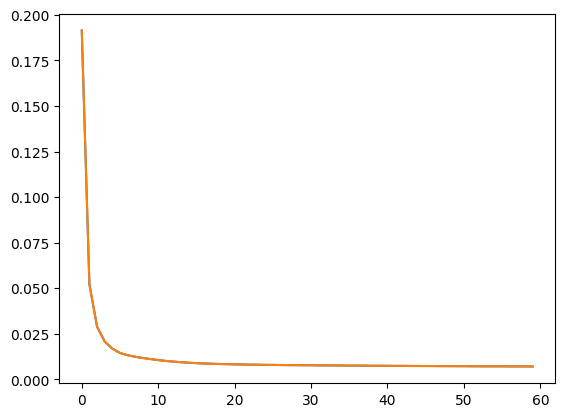


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 32]}, 'max_epochs': 60, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [32, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_features=32, bias=True)
      (5): Identity()
    )
  )


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 39.9 K | train
2 | decoder       | MLP     | 40.1 K | train
--------------------------------------------------
80.0 K    Trainable params
0         Non-trainable params
80.0 K    Total params
0.320     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo__bottleneck_32_v1__reconstructed_outputs.csv


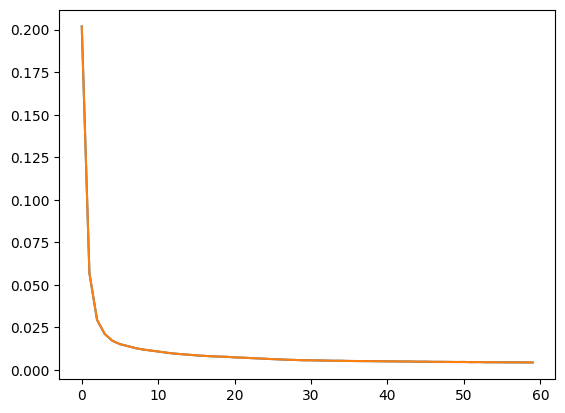


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [64, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 64]}, 'max_epochs': 60, 'nickname': 'bottleneck_64', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'use_covariance_loss': False, 'decoder_sizes': [64, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_features=64, bias=True)
      (5): Identity()
    )
  )


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 43.0 K | train
2 | decoder       | MLP     | 43.2 K | train
--------------------------------------------------
86.2 K    Trainable params
0         Non-trainable params
86.2 K    Total params
0.345     Total estimated model params size (MB)
17        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo__bottleneck_64_v1__reconstructed_outputs.csv


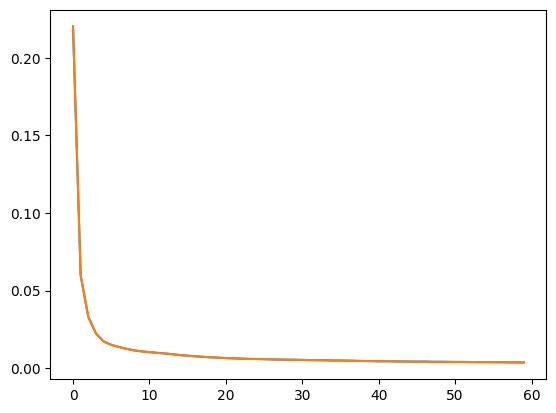

In [9]:
# Set the seed
set_random_seeds(seed=random_seed_number)
# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": "../data/uk_census_all.csv",
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        },
        "decoder": {
            "sizes":  "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}

data_nickname = "census_geodemo"
# Generate YAML files with varying latent space sizes
for _latent_size in bottleneck_sizes:
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    encoder_shape = [ layer1_dim, layer2_dim, _latent_size]
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_shape
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_shape[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 2], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 1}}, 'max_epochs': 60, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 1, 'use_covariance_loss': False, 'decoder_sizes': [2, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negat

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.0 K | train
2 | decoder       | MLP     | 37.2 K | train
--------------------------------------------------
74.2 K    Trainable params
0         Non-trainable params
74.2 K    Total params
0.297     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparse__bottleneck_2_v1__reconstructed_outputs.csv


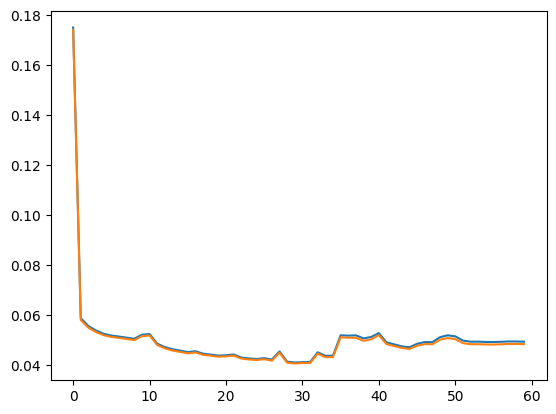


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 4], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 2}}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 2, 'use_covariance_loss': False, 'decoder_sizes': [4, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negat

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.2 K | train
2 | decoder       | MLP     | 37.4 K | train
--------------------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparse__bottleneck_4_v1__reconstructed_outputs.csv


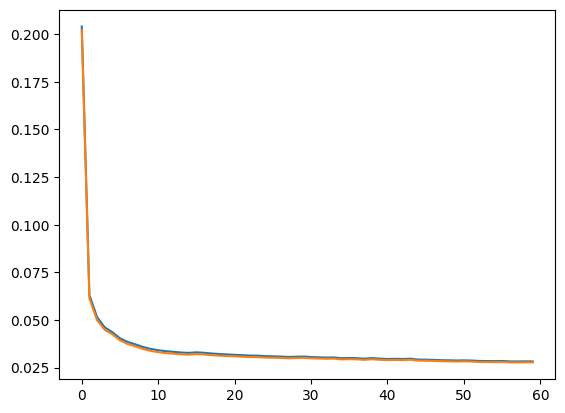


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 8], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 60, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'use_covariance_loss': False, 'decoder_sizes': [8, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negat

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.6 K | train
2 | decoder       | MLP     | 37.8 K | train
--------------------------------------------------
75.4 K    Trainable params
0         Non-trainable params
75.4 K    Total params
0.302     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparse__bottleneck_8_v1__reconstructed_outputs.csv


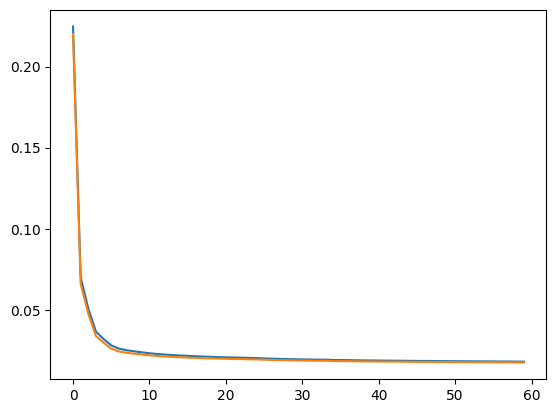


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 16], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 60, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 8, 'use_covariance_loss': False, 'decoder_sizes': [16, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(n

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 38.4 K | train
2 | decoder       | MLP     | 38.6 K | train
--------------------------------------------------
76.9 K    Trainable params
0         Non-trainable params
76.9 K    Total params
0.308     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparse__bottleneck_16_v1__reconstructed_outputs.csv


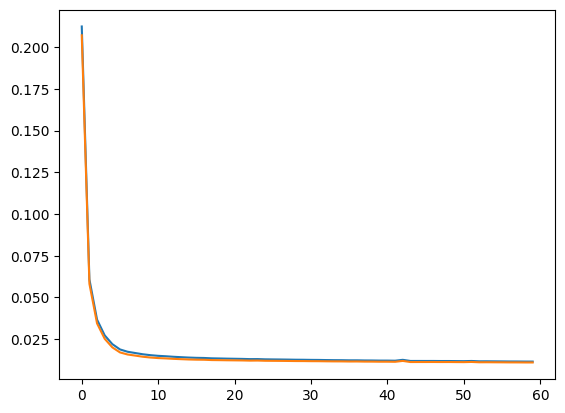


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 32], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 60, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 16, 'use_covariance_loss': False, 'decoder_sizes': [32, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 39.9 K | train
2 | decoder       | MLP     | 40.1 K | train
--------------------------------------------------
80.0 K    Trainable params
0         Non-trainable params
80.0 K    Total params
0.320     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparse__bottleneck_32_v1__reconstructed_outputs.csv


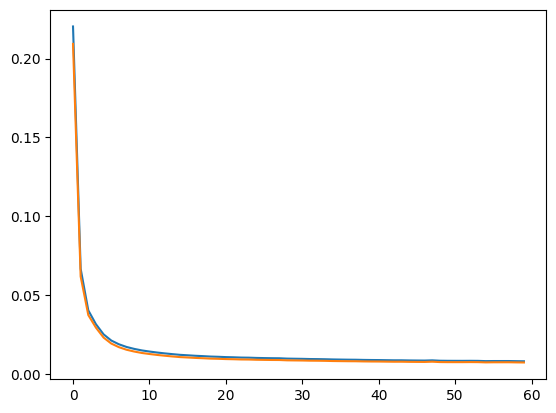


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [64, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 64], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 32}}, 'max_epochs': 60, 'nickname': 'bottleneck_64', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparse', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 32, 'use_covariance_loss': False, 'decoder_sizes': [64, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 43.0 K | train
2 | decoder       | MLP     | 43.2 K | train
--------------------------------------------------
86.2 K    Trainable params
0         Non-trainable params
86.2 K    Total params
0.345     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparse__bottleneck_64_v1__reconstructed_outputs.csv


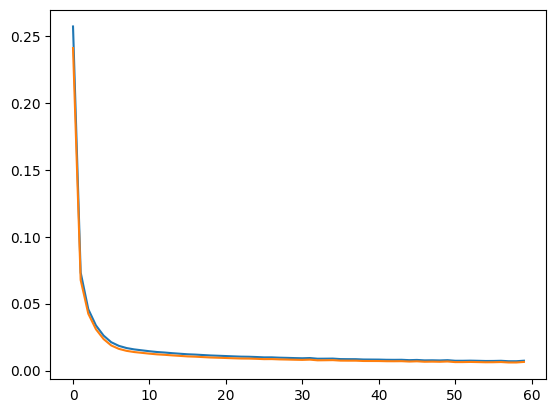

In [10]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": "../data/uk_census_all.csv",
        "nickname": "PLACEHOLDER",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparse"

# Generate YAML files with varying latent space sizes
for _latent_size in bottleneck_sizes:
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    encoder_shape = [layer1_dim, layer2_dim, _latent_size]
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_shape
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_shape[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = f"bottleneck_{_latent_size}"
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [2, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 2], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 1}}, 'max_epochs': 60, 'nickname': 'bottleneck_2', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 1, 'decoder_sizes': [2, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_fea

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.0 K | train
2 | decoder       | MLP     | 37.2 K | train
--------------------------------------------------
74.2 K    Trainable params
0         Non-trainable params
74.2 K    Total params
0.297     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparsecov__bottleneck_2_v1__reconstructed_outputs.csv


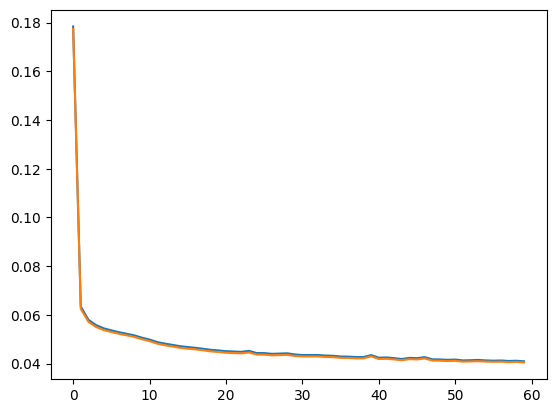


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [4, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 4], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 2}}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 2, 'decoder_sizes': [4, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_fea

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.2 K | train
2 | decoder       | MLP     | 37.4 K | train
--------------------------------------------------
74.6 K    Trainable params
0         Non-trainable params
74.6 K    Total params
0.299     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparsecov__bottleneck_4_v1__reconstructed_outputs.csv


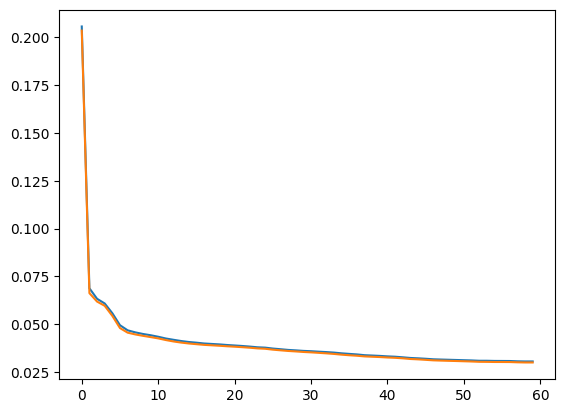


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [8, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 8], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 60, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'decoder_sizes': [8, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out_fea

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 37.6 K | train
2 | decoder       | MLP     | 37.8 K | train
--------------------------------------------------
75.4 K    Trainable params
0         Non-trainable params
75.4 K    Total params
0.302     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparsecov__bottleneck_8_v1__reconstructed_outputs.csv


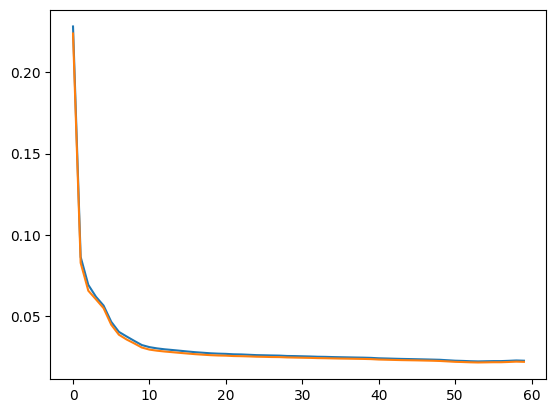


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [16, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 16], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 60, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 8, 'decoder_sizes': [16, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, out

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 38.4 K | train
2 | decoder       | MLP     | 38.6 K | train
--------------------------------------------------
76.9 K    Trainable params
0         Non-trainable params
76.9 K    Total params
0.308     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparsecov__bottleneck_16_v1__reconstructed_outputs.csv


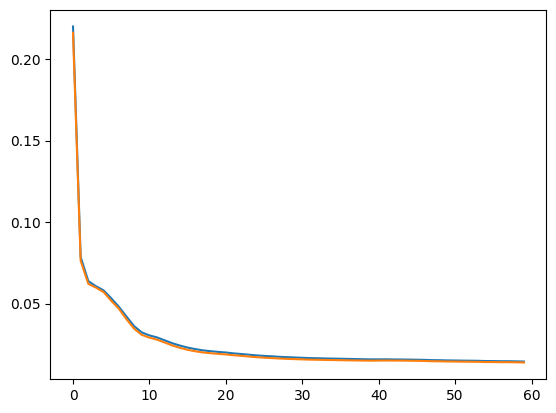


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [32, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 32], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 60, 'nickname': 'bottleneck_32', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 16, 'decoder_sizes': [32, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, o

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 39.9 K | train
2 | decoder       | MLP     | 40.1 K | train
--------------------------------------------------
80.0 K    Trainable params
0         Non-trainable params
80.0 K    Total params
0.320     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparsecov__bottleneck_32_v1__reconstructed_outputs.csv


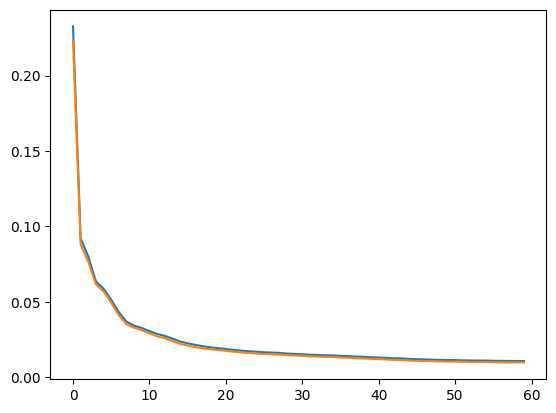


geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [64, 96, 128]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [128, 96, 64], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 32}}, 'max_epochs': 60, 'nickname': 'bottleneck_64', 'save_latent': 'csv', 'version': '1'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_sparsecov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/60epoch_scan_extalayers'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 32, 'decoder_sizes': [64, 96, 128, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=128, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=128, out_features=96, bias=True)
      (3): LeakyReLU(negative_slope=0.01)
      (4): Linear(in_features=96, o

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 43.0 K | train
2 | decoder       | MLP     | 43.2 K | train
--------------------------------------------------
86.2 K    Trainable params
0         Non-trainable params
86.2 K    Total params
0.345     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/60epoch_scan_extalayers/census_geodemo_sparsecov__bottleneck_64_v1__reconstructed_outputs.csv


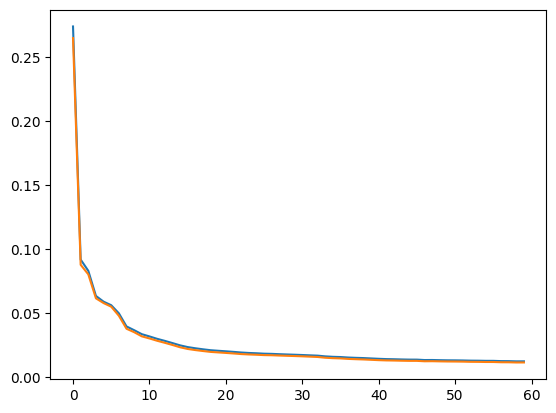

In [12]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": "../data/uk_census_all.csv",
        "nickname": "census_geodemo_sparse",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": "1",
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "encoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": "PLACEHOLDER",
            "activation": "LeakyReLU"
        }
    }
}


data_nickname = "census_geodemo_sparsecov"

# Generate YAML files with varying latent space sizes
for _latent_size in bottleneck_sizes:
    ae_nickname = f"bottleneck_{_latent_size}"
    yaml_config = BASE_YAML.copy()
    encoder_shape = [layer1_dim, layer2_dim, _latent_size]
    yaml_config["autoencoder"]["encoder"]["sizes"] = encoder_shape
    yaml_config["autoencoder"]["decoder"]["sizes"] = encoder_shape[::-1] #reversed for encoder
    yaml_config["autoencoder"]["nickname"] = f"bottleneck_{_latent_size}"
    yaml_config["autoencoder"]["nickname"] = ae_nickname
    yaml_config["data"]["nickname"] = data_nickname
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = int(_latent_size/2)


    config_path = os.path.join(OUTPUT_DIR, f"config_{data_nickname}_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)


    autoencoder_train_latent.main(config_path, create_latent=True,save_reco_error=True, verbose=True)
    plot_loss(WORKING_DIR,data_nickname,ae_nickname)

In [4]:
# Initialize lists to store RMSE and MAE
errors = {}


n_features = data_table.shape[1]
data = data_table

def compute_errors(original, reconstructed):
    """Compute RMSE and MAE between original and reconstructed data."""
    error = original - reconstructed
    return np.sqrt(np.mean(error ** 2)), np.mean(np.abs(error))

# Fit PCA once with the maximum number of components
pca = PCA(n_components=n_features - 1)
transformed = pca.fit_transform(data)

# Process PCA reconstruction
errors["PCA"] = {"rmse": [], "mae": []}
for n in tqdm(bottleneck_sizes, desc="Processing PCA"):
    reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
    #save the reconstructed data
    pd.DataFrame(reconstructed_pca, index=data.index, columns=data.columns).to_csv(f"../data/PCA/{n}_components.csv")
    rmse, mae = compute_errors(data, reconstructed_pca)
    errors["PCA"]["rmse"].append(rmse)
    errors["PCA"]["mae"].append(mae)

Processing PCA: 100%|██████████| 6/6 [03:59<00:00, 39.96s/it]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm



def load_reconstructed_data(file_path):
    """Load reconstructed data from a CSV file."""
    return pd.read_csv(file_path, index_col="ID")

def process_reconstruction(label, file_pattern, bottleneck_sizes, original_data):
    """Process reconstruction for a given method and store errors."""
    errors[label] = {"rmse": [], "mae": []}
    for n in tqdm(bottleneck_sizes, desc=f"Processing {label}"):
        reconstructed = load_reconstructed_data(file_pattern.format(n=n))
        rmse, mae = compute_errors(original_data, reconstructed)
        print(f"{label} - {n} components: RMSE = {rmse:.2f}, MAE = {mae:.2f}")
        errors[label]["rmse"].append(rmse)
        errors[label]["mae"].append(mae)

def plot_errors(metric, ylabel, title):
    """Plot errors for different reconstruction methods."""
    for label, data in errors.items():
        plt.plot(bottleneck_sizes, data[metric], marker='o', label=label)
    plt.xlabel("Number of PCA Components / TOPK Size")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid()



# Process Autoencoder reconstructions
process_reconstruction("Autoencoder", f"{WORKING_DIR}/census_geodemo__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)
process_reconstruction("Autoencoder (sparse)", f"{WORKING_DIR}/census_geodemo_sparse__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)
process_reconstruction("Autoencoder (sparce_cov)", f"{WORKING_DIR}/census_geodemo_sparsecov__bottleneck_{{n}}_v1__reconstructed_outputs.csv", bottleneck_sizes, data)

# Generate plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_errors("rmse", "RMSE", "RMSE vs. # of Dimensions")

plt.subplot(1, 2, 2)
plot_errors("mae", "MAE", "MAE vs. # of Dimensions")

plt.tight_layout()
plt.show()


NameError: name 'data' is not defined